# Big Data Analytics on the NYC Yellow Taxi Trip Records (Jul–Sep 2025)
Data Source: Data Source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page 


# Introduction
The New York City Taxi & Limousine Commission (TLC) publishes monthly trip records of roughly 3-4 million yellow-taxi trips per month, distributed as Parquet files with a stable but evolving schema. Across the three months selected for analysis (July, August, September 2025), the dataset comprises on the order of 10–12 million records, which is above the threshold at which conventional in-memory single-node tooling (e.g. pandas, scikit-learn) becomes uncomfortable: not catastrophic, but slow, memory-fragile, and difficult to parallelise without bespoke engineering. This is the regime in which a distributed compute engine such as Apache Spark delivers value, through lazy evaluation, partition-parallel execution, and a query optimiser (Catalyst) that can rewrite logical plans into efficient ones (Zaharia et al., 2016).

The project is structured around four tasks:
1. **Data Preparation**- ingest three months of Parquet, clean, and standardise the schema.
2. **Exploratory Data Analysis (EDA)** - answer five questions across temporal, spatial, trip, and payment dimensions, with explicit attention to the cost of shuffle.
3. **Distributed Clustering**- apply MLlib KMeans across two complementary feature spaces (spatial demand, trip economics) and assess quality with the silhouette score.
4. **Distributed Supervised Learning**- derive pseudo-labels from clustering and demand thresholds, then train a Decision Tree and Logistic Regression classifier and compare their behaviour at scale.

The aim is not merely to demonstrate that PySpark runs, but to reflect critically on why each design choice was made, what was traded away, and how the same workload would degrade or improve under realistic data-volume scaling.


## Data Preparation

### 2.1 Environment and Spark Session

A Spark session is the canonical entry point for the DataFrame API. Several configuration choices materially affect performance and are set explicitly rather than left at default:

- spark.sql.shuffle.partitions = 64: The Spark default of 200 is calibrated for clusters with hundreds of cores; on a single workstation it produces tiny tasks and excessive scheduler overhead. Empirical guidance from Karau & Warren (2017) suggests aiming for 2-4 partitions per available core, which on an 8-core laptop gives 16-32. A slightly larger value of 64 is used here to keep individual shuffle blocks well below 200 MB while keeping task count manageable.
- spark.sql.adaptive.enabled = true: Adaptive Query Execution (AQE), introduced in Spark 3.0, allows the optimiser to coalesce shuffle partitions, switch join strategies, and skip skewed partitions at runtime using the actual statistics of intermediate stages. It is essentially free and is enabled by default in Spark 3.2+, but we make the choice explicit for documentation purposes.
- spark.sql.parquet.filterPushdown = true: Parquet pushdown allows row-group skipping based on min/max statistics, which is decisive when we filter to a narrow date window. Without it, every byte of every row group is read.

The configuration is intentionally defensive: it favours correctness and reproducibility over peak benchmark numbers.

In [1]:
!pip -q install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importing Neccessary frameworks
import os
import time
from contextlib import contextmanager

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.request import urlretrieve
from urllib.parse import quote

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# to time Spark actions 
@contextmanager
def timed(label: str):
    t0 = time.time()
    yield
    print(f"  [timed] {label}: {time.time() - t0:0.2f}s")

In [3]:
# Create a Spark-specific temp directory in a path you control
SPARK_TEMP_DIR = "C:/spark_temp"        
os.makedirs(SPARK_TEMP_DIR, exist_ok=True)


In [4]:
# Build the SparkSession with configuration justified above
spark = (
    SparkSession.builder
        .appName("NYC_Yellow_Taxi")
        .config("spark.sql.shuffle.partitions", "32")
        .config("spark.local.dir", SPARK_TEMP_DIR) 
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.sql.adaptive.skewJoin.enabled", "true")
        .config("spark.sql.parquet.filterPushdown", "true")
        .config("spark.driver.memory", "6g")
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")
print(f"Shuffle partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"AQE enabled:        {spark.conf.get('spark.sql.adaptive.enabled')}")



Spark version: 3.5.8
Default parallelism: 4
Shuffle partitions: 32
AQE enabled:        true


### 2.2 Ingestion of Three Monthly Parquet Files from a Public Repository
To ensure full reproducibility of this analysis, the three monthly Parquet files were uploaded to a public github repository. The notebook downloads each file once via urllib from raw.githubusercontent.com (GitHub's raw-content domain), caches it locally, and skips the download on subsequent
runs. This makes the notebook portable across machines without depending on git being installed.

Note that PySpark's Parquet reader operates on a filesystem path rather than over HTTP - spark.read.parquet() cannot read directly from an https:// URL. therefore, the files were downloaded first and then point Spark at the local copies.

The three files are read as explicit positional arguments to a single

raw_data = spark.read.parquet(path_jul, path_aug, path_sep)

Spark's reader accepts multiple paths in this form and treats them as a single logical scan over the union of files.This makes the dependency on each file explicit and self-documenting, which is useful when the dataset is small and bounded rather than open-ended. Schema reconciliation across the files is handled automatically by Spark; the resulting DataFrame contains the union of all rows with a single, unified schema.
Parquet is well-suited to this workload. It is a columnar format with row groups, dictionary encoding, and per-row-group statistics blocks. Spark only reads columns that downstream operations actually require, so dropping unused columns(Section2.3) costs essentially nothing at scan time (Vohra, 2016). The combined data are roughly 190 MB compressed but expand to several gigabytes once decoded into JVM memory.

In [5]:
# Where to put the data locally
data_dir = "Dataset"
os.makedirs(data_dir, exist_ok=True)

# Base URL for raw GitHub content
url_raw_base = "https://raw.githubusercontent.com/Medynal/yellow-taxi/main/Dataset"

files = [
    "yellow_tripdata_2025-07.parquet",
    "yellow_tripdata_2025-08.parquet",
    "yellow_tripdata_2025-09.parquet",
]

for fname in files:
    local_path = os.path.join(data_dir, fname)
    if os.path.exists(local_path):
        size_mb = os.path.getsize(local_path) / (1024**2)
        print(f"already have {fname}  ({size_mb:.1f} MB)")
        continue
    url = f"{url_raw_base}/{quote(fname)}"
    print(f"downloading {fname} ...")
    urlretrieve(url, local_path)
    size_mb = os.path.getsize(local_path) / (1024**2)
    print(f" saved as {local_path} ({size_mb:.1f} MB)")



already have yellow_tripdata_2025-07.parquet  (63.8 MB)
already have yellow_tripdata_2025-08.parquet  (59.4 MB)
already have yellow_tripdata_2025-09.parquet  (69.1 MB)


In [6]:
print(os.listdir(data_dir))

['yellow_tripdata_2025-07.parquet', 'yellow_tripdata_2025-08.parquet', 'yellow_tripdata_2025-09.parquet']


In [7]:
path_July = f"{data_dir}/yellow_tripdata_2025-07.parquet"
path_Aug = f"{data_dir}/yellow_tripdata_2025-08.parquet"
path_Sep = f"{data_dir}/yellow_tripdata_2025-09.parquet"

raw_data = spark.read.parquet(path_July, path_Aug, path_Sep)

In [8]:
print("Partitions:", raw_data.rdd.getNumPartitions())

Partitions: 4


In [9]:
raw_data.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-07-01 00:29:37|  2025-07-01 00:45:30|              1|          7.3|         1|                 N|         138|    

In [10]:
raw_data.printSchema

<bound method DataFrame.printSchema of DataFrame[VendorID: int, tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, passenger_count: bigint, trip_distance: double, RatecodeID: bigint, store_and_fwd_flag: string, PULocationID: int, DOLocationID: int, payment_type: bigint, fare_amount: double, extra: double, mta_tax: double, tip_amount: double, tolls_amount: double, improvement_surcharge: double, total_amount: double, congestion_surcharge: double, Airport_fee: double, cbd_congestion_fee: double]>

In [11]:
raw_data.columns
n_raw = raw_data.count()


### 2.3 Profiling Data Quality: Nulls and Duplicates

Before any cleaning, two integrity checks were run. Both are framed as single-pass aggregations to avoid the cost of repeatedly scanning the 11.7M-row dataset.

#### Null profiling

For every column in the projected DataFrame, null count and the percentage of the dataset they represent were checked. 

The result confirms that:Key columns like timestamps, locations and fares are fully populated. Roughly 26% of rows have nulls in passenger_count, ratecode_id, airport_fee, and congestion_surcharge and the counts are identical across these four columns. Identical nullcounts across multiple columns is the signature of systematic missingness, typically caused by a particular vendor's meter software not populating those fields. This is "missing not at random" (MNAR) and has an important implication: dropping the affected rows would over-represent other vendors and bias the dataset. 

#### Duplicate profiling
There's no unique identifier column in the dataset. Therefore, it is Naturally possible for two trips to have the same record because.Since the duplicate counts is negligible (under 1%), no deduplication step will be performed. 

In [12]:
# Checking for null values in each column
null_counts = [
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in raw_data.columns]

total_rows = raw_data.count()

null_row = raw_data.agg(*null_counts).toPandas().T

null_row.columns = ["null_count"]
null_row["null_pct"] = (null_row["null_count"] / total_rows * 100).round(3)
null_row = null_row.sort_values("null_count", ascending=False)
null_row["null_count"] = null_row["null_count"].astype(int)

print(f"Total rows: {total_rows:,}\n")
null_row

Total rows: 11,724,069



,null_count,null_pct
passenger_count,2992184,25.522
congestion_surcharge,2992184,25.522
store_and_fwd_flag,2992184,25.522
RatecodeID,2992184,25.522
Airport_fee,2992184,25.522
tpep_dropoff_datetime,0,0.000
VendorID,0,0.000
tpep_pickup_datetime,0,0.000
DOLocationID,0,0.000
payment_type,0,0.000


In [13]:
# Null counts per vendor to validate null values
null_by_vendor = (
    raw_data.groupBy("VendorID")
    .agg(
        F.count("*").alias("total_rows"),
        F.sum(F.col("passenger_count").isNull().cast("int")).alias("null_passenger"),
        F.sum(F.col("RatecodeID").isNull().cast("int")).alias("null_ratecode"),
        F.sum(F.col("Airport_Fee").isNull().cast("int")).alias("null_airport_fee"),
        F.sum(F.col("congestion_surcharge").isNull().cast("int")).alias("null_congestion"),
        F.sum(F.col("store_and_fwd_flag").isNull().cast("int")).alias("null_store_and_fwd_flag")
    )
    .orderBy("VendorID")
    .toPandas())

# Add percentage columns for each null check
for col in ["null_passenger", "null_ratecode", "null_airport_fee", "null_congestion", "null_store_and_fwd_flag"]:
    null_by_vendor[f"{col}_pct"] = (null_by_vendor[col] / null_by_vendor["total_rows"] * 100).round(2)

null_by_vendor

,VendorID,total_rows,null_passenger,null_ratecode,null_airport_fee,null_congestion,null_store_and_fwd_flag,null_passenger_pct,null_ratecode_pct,null_airport_fee_pct,null_congestion_pct,null_store_and_fwd_flag_pct
0,1,2199210,374122,374122,374122,374122,374122,17.01,17.01,17.01,17.01,17.01
1,2,9357806,2610306,2610306,2610306,2610306,2610306,27.89,27.89,27.89,27.89,27.89
2,6,7756,7756,7756,7756,7756,7756,100.00,100.00,100.00,100.00,100.00
3,7,159297,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00


In [14]:
# duplicate rows
distinct_rows = raw_data.distinct().count()
duplicate = total_rows - distinct_rows
dup_summary = pd.DataFrame({
    "check": ["Total rows", "duplicate rows"],
    "count": [total_rows, duplicate]})
dup_summary["pct_of_total"] = ((dup_summary["count"] / total_rows * 100).round(3))
dup_summary

,check,count,pct_of_total
0,Total rows,11724069,100.0
1,duplicate rows,1,0.0


### 2.4 Column Selection and Renaming

The TLC dictionary specifies 20 columns, but some are redundant for the analyses. 

store_and_fwd_flag- relevant for audits, not for trip-pattern modelling.
improvement_surcharge, mta_tax, extra, tolls_amount cbd_congestion_fee: these are constituents of total_amount and would introduce multicollinearity in any fare-based model.

Airport_fee, congestion_surcharge and cbd_congestion_fee: kept conditionally and will be treated as engineered booleans rather than continuous features.congestion_surcharge provides geographic indicator (any trip touching Manhattan south of 96th) and The newer cbd_congestion_fee (south of 60th, introduced January 2025) is highly correlated with the older surcharge and adds little additional signal beyond what the pickup/drop-off zone IDs already encode.

tip_amount was retained despite a similar arithmetic relationship like other dropped fees, because tipping is a behavioural decision by the passenger and carries information no other column captures.
Camel-case column names are normalised to snake-case for column name uniformity.
This step illustrates a general principle for distributed pipelines: prune as early as possible


In [15]:
kept_columns = [
    F.col("VendorID").alias("vendor_id"),
    F.to_timestamp(F.col("tpep_pickup_datetime")).alias("pickup_dt"),#cast to timestamp for arithimetic purpose
    F.to_timestamp(F.col("tpep_dropoff_datetime")).alias("dropoff_dt"),#cast to timestamp for arithimetic purpose
    F.col("passenger_count").cast("int").alias("passenger_count"), #cast as int from bigint for proper memory usage
    F.col("trip_distance").alias("trip_distance"),
    F.col("RatecodeID").cast("int").alias("ratecode_id"),
    F.col("PULocationID").alias("pu_zone"),
    F.col("DOLocationID").alias("do_zone"),
    F.col("payment_type").cast("int").alias("payment_type"),
    F.col("fare_amount").alias("fare_amount"),
    F.col("tip_amount").alias("tip_amount"),
    F.col("total_amount").alias("total_amount"),
    F.col("Airport_fee").alias("airport_fee"),
    F.col("congestion_surcharge").alias("congestion_surcharge"),
    F.col("cbd_congestion_fee").alias("cbd_congestion_fee"),
]

yellowcab_df = raw_data.select(*kept_columns)
yellowcab_df.printSchema()
print(f"\nColumns retained: {len(yellowcab_df.columns)} (down from {len(raw_data.columns)})")


root
 |-- vendor_id: integer (nullable = true)
 |-- pickup_dt: timestamp (nullable = true)
 |-- dropoff_dt: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- ratecode_id: integer (nullable = true)
 |-- pu_zone: integer (nullable = true)
 |-- do_zone: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)


Columns retained: 15 (down from 20)


In [16]:
yellowcab_df.describe().show()

+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+--------------------+------------------+
|summary|         vendor_id|   passenger_count|    trip_distance|       ratecode_id|           pu_zone|           do_zone|      payment_type|       fare_amount|       tip_amount|      total_amount|        airport_fee|congestion_surcharge|cbd_congestion_fee|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+--------------------+------------------+
|  count|          11724069|           8731885|         11724069|           8731885|          11724069|          11724069|          11724069|          11724069|         11724069|          11724069|            8731885|         

### 2.4 Profiling Data Quality- Abnormal Values

Before any cleaning, the data queality was inspected. Three categories of issue are typical of TLC releases and all three appear here (Donovan & Work, 2017; Schneider, 2015):

1. **Stale or future timestamps** - Some pickup or dropdate contains stale or future timestamp. These reflect VendorID-side clock skew and meter rollover.
2. **Negative monetary values** - negative fares arise from refunds or vendor-side adjustments (Donovan & Work, 2017). They are not informative for trip-pattern modelling.
3. **Implausible distances and durations** - despite having an average value of approximately 7 miles, trip_distance has a max value of 397994.37 miles . This is roughly 1.6× the distance to the Moon, and is plainly a meter fault.


In [17]:
#checking for data quality in a Single multi-aggregation pass 
quality = yellowcab_df.agg(
    # Out of range timestamps
    F.sum((F.col("pickup_dt") < F.to_timestamp(F.lit("2025-07-01"))).cast("int")).alias("pickup_before_window"),
    F.sum((F.col("pickup_dt") >= F.to_timestamp(F.lit("2025-10-01"))).cast("int")).alias("pickup_after_window"),
    # Abnormal numerics
    F.sum((F.col("fare_amount") < 0).cast("int")).alias("negative_fare"),
    F.sum((F.col("fare_amount") > 81.40).cast("int")).alias("negative_farre"),
    F.sum((F.col("total_amount") < 0).cast("int")).alias("negative_total"),
    F.sum((F.col("trip_distance") <= 0).cast("int")).alias("nonpositive_distance"),
    F.sum((F.col("trip_distance") > 100).cast("int")).alias("distance_gt_100mile"),
    F.sum((F.col("passenger_count") == 0).cast("int")).alias("zero_passengers"),
    F.sum((F.col("passenger_count") > 6).cast("int")).alias("over_six_passengers"),
    F.sum((F.col("congestion_surcharge") > 6).cast("int")).alias("neg_congestion_surcharge"),
    F.sum((F.col("cbd_congestion_fee") > 6).cast("int")).alias("neg_cbd_congestion_fee")
).toPandas().T
quality.columns = ["count"]
quality["pct_of_total"] = (quality["count"] / total_rows * 100).round(3)
quality


,count,pct_of_total
pickup_before_window,8,0.000
pickup_after_window,1,0.000
negative_fare,760997,6.491
negative_farre,115356,0.984
negative_total,242887,2.072
nonpositive_distance,353441,3.015
distance_gt_100mile,733,0.006
zero_passengers,60002,0.512
over_six_passengers,33,0.000
neg_congestion_surcharge,0,0.000


**Data quality report:**

- About 26 % of rows have a null passenger_count and ratecode_id. These nulls are systematic (likely arising from a particular vendor-software version) rather than random; this matters because dropping them would bias the sample. Modal value will be used instead.
- Negative fares are rare and are removed outright - they cannot be sensibly imputed.
- A non-trivial fraction of trips falls outside the July–September 2025 window. 
- Trip distances above 100 miles are similarly suspect and are capped (winsorised) rather than dropped wholesale, which preserves the row count for the rest of the columns.
- Passenger count above the lagal limit are dropped because of the suspecting surrounding data, although this might be due to meter glitches.
- Zero passenger count are replaced with the modal value. Zero values might arise from missing input from the driver.
- The data is restricted to trip within legal speed in NYC.
- according to the data dictionary, tips field is automatically populated for credit card tips. Cash tips are not included. therefore, tips percentage calculation is restricted to card payment only.

### 2.5 Cleaning Pipeline

The cleaning is implemented as a single chained transformation. Spark's lazy evaluation collapses this into one optimised physical plan, so chaining 10 transformations costs roughly the same as chaining 2.

- Negative fares are rare and are removed outright - they cannot be sensibly imputed.
- A non-trivial fraction of trips falls outside the July–September 2025 window. These are filtered to enforce the dataset duration as stated from the source.
- Trip distances above 100 miles are similarly suspect and are capped (winsorised) rather than dropped wholesale, which preserves the row count for the rest of the columns.
- Passenger count above the lagal limit are dropped because of the suspecting surrounding data, although this might be due to meter glitches.
- Zero passenger count are replaced with the modal value. Zero values might arise from missing input from the driver.
- The data is restricted to trip within legal speed in NYC.

In [18]:
start_window = "2025-07-01 00:00:00"
end_window   = "2025-10-01 00:00:00"

# Compute a fare cap from quantiles for principled winsorisation.
fare_q99 = yellowcab_df.approxQuantile("fare_amount", [0.99], 0.001)[0]
dist_q99 = yellowcab_df.approxQuantile("trip_distance", [0.99], 0.001)[0]
print(f"99th percentile fare:     ${fare_q99:,.2f}")
print(f"99th percentile distance: {dist_q99:,.2f} miles")



99th percentile fare:     $81.40
99th percentile distance: 19.79 miles


In [19]:
clean = (
    yellowcab_df
    # 1. Restrict to the data's stated date window
    .filter((F.col("pickup_dt") >= F.to_timestamp(F.lit(start_window))) &
            (F.col("pickup_dt") <  F.to_timestamp(F.lit(end_window))))
    # 2. Drop negative monetary values
    .filter((F.col("fare_amount")  >= 0) &
            (F.col("total_amount") >= 0))
    # 3. Drop trips with non-positive distance 
    .filter(F.col("trip_distance") > 0)
    # 4. Impute nulls with modal/standard values
    .fillna({
        "passenger_count": 1,        # mode is 1
        "ratecode_id": 1,            # 1 = Standard rate
        "airport_fee": 0.0,
        "congestion_surcharge": 0.0,
    })
    # 5. Winsorise extreme outliers at the 99th percentile
    .withColumn("fare_amount",   F.least(F.col("fare_amount"),   F.lit(fare_q99)))
    .withColumn("trip_distance", F.least(F.col("trip_distance"), F.lit(dist_q99)))
    # Treat 0 as missing input from driver and impute the mode
    .withColumn("passenger_count",
            F.when(F.col("passenger_count") == 0, F.lit(1)) # mode= 1
             .otherwise(F.col("passenger_count")))
    # Drop rows where passenger_count > 6 - meter glitches with suspect surrounding data
    .filter(F.col("passenger_count") <= 6)
    .withColumn("trip_duration_min",
        (F.unix_timestamp("dropoff_dt") - F.unix_timestamp("pickup_dt")) / 60.0)
    # Restrict trip duration to 180 min
    .filter((F.col("trip_duration_min") > 1) & (F.col("trip_duration_min") < 180))
    .withColumn("pickup_hour",      F.hour("pickup_dt"))
    .withColumn("pickup_dayofweek", F.dayofweek("pickup_dt"))   # 1=Sunday … 7=Saturday
    .withColumn("pickup_date",      F.to_date("pickup_dt"))
    .withColumn("is_weekend",       F.col("pickup_dayofweek").isin(1, 7).cast("int"))
    .withColumn("avg_speed_mph",
        F.col("trip_distance") / (F.col("trip_duration_min") / 60.0))
    # restrict average speed to legal permit speed in NYC- 80mph
    .filter((F.col("avg_speed_mph") > 0) & (F.col("avg_speed_mph") < 80))
    # 8. Tip percentage (only meaningful for credit-card-paid trips, payment_type==1)
    .withColumn("tip_pct",
        F.when(F.col("payment_type") == 1,
               F.col("tip_amount") / F.greatest(F.col("fare_amount"), F.lit(0.01)) # playing safe for 0 fare
        ).otherwise(F.lit(None).cast("double"))))

# Cache because every subsequent task hits this DataFrame several times.
clean_yellowcab = clean.persist()

with timed("count() on cleaned DataFrame (forces cache materialisation)"):
    n_clean = clean_yellowcab .count()
print(f"\nClean row count : {n_clean:,}")
print(f"Rows removed    : {n_raw - n_clean:,} ({(n_raw - n_clean)/n_raw*100:0.2f}%)")


  [timed] count() on cleaned DataFrame (forces cache materialisation): 40.33s

Clean row count : 10,475,346
Rows removed    : 1,248,723 (10.65%)


In [20]:
clean_yellowcab.show()

+---------+-------------------+-------------------+---------------+-------------+-----------+-------+-------+------------+-----------+----------+------------+-----------+--------------------+------------------+------------------+-----------+----------------+-----------+----------+------------------+-------------------+
|vendor_id|          pickup_dt|         dropoff_dt|passenger_count|trip_distance|ratecode_id|pu_zone|do_zone|payment_type|fare_amount|tip_amount|total_amount|airport_fee|congestion_surcharge|cbd_congestion_fee| trip_duration_min|pickup_hour|pickup_dayofweek|pickup_date|is_weekend|     avg_speed_mph|            tip_pct|
+---------+-------------------+-------------------+---------------+-------------+-----------+-------+-------+------------+-----------+----------+------------+-----------+--------------------+------------------+------------------+-----------+----------------+-----------+----------+------------------+-------------------+
|        1|2025-07-01 00:29:37|2025-0

### 2.6 Reflection on Data Preparation

The cleaning step removes about 10% of the raw dataset . Removing far more (say 20 %+) would suggest over-aggressive filtering and a distorted sample; removing less than 1 % would suggest important quality issues are being missed. The figure observed here is consistent with TLC quality reports for prior years (Donovan & Work, 2017).

Two trade-offs are worth flagging:

1. **Imputation vs. dropping rows for nulland zero passenger_count .** Dropping the 26 % of rows with null passenger counts would have made the dataset materially less representative - the nulls are concentrated in particular vendors and rate-code categories, so the missingness is not at random (MNAR). Modal imputation is a pragmatic compromise that preserves volume.

2. **Winsorisation at the 99th percentile vs. removal.** Winsorisation preserves the row but caps the extreme value, which protects clustering centroids and KMeans (which is highly sensitive to outliers) without throwing data away. It does, however, compress the tail of the fare distribution and would bias any analysis that focuses specifically on long, expensive trips. For this project, where the interest lies in modal patterns, the trade is favourable
According to the data dictionary, tips field is automatically populated for credit card tips. Cash tips are not included. therefore, tips percentage calculation is restricted to card payment only.
The cleaned DataFrame is **persisted** because every subsequent task (EDA, clustering, supervised learning) re-reads it. Without persist() Spark would re-execute the entire transformation chain three or four times, paying the I/O and CPU cost each time. With persist(), the cost is paid once.

## 3. Exploratory Data Analysis and Performance Optimisation

### Five Exploratory Questions

The questions below are spread across the four dimensions: temporal, spatial, trip, and payment.

| # | Dimension      | Question                                                                  
|---|----------------|--------------------------------------------------------------------------
| Q1| Temporal       | How does pickup demand vary by hour-of-day and day-of-week?            
| Q2| Spatial        | Which 20 pickup zones generate the most trips and revenue?                |
| Q3| Trip           | How does average fare scale with trip distance?                  |
| Q4| Payment        | What is the tipping behaviour by payment type and zone?                   | 
| Q5| Joint temporal/economic | Is there a "rush-hour fare premium" i.e. higher fare/mile during rush hour? |



### Q1: Temporal Demand by Hour and Day-of-Week
How does pickup demand vary by hour-of-day and day-of-week?            


In [21]:
sns.set_theme(style="whitegrid", context="talk")

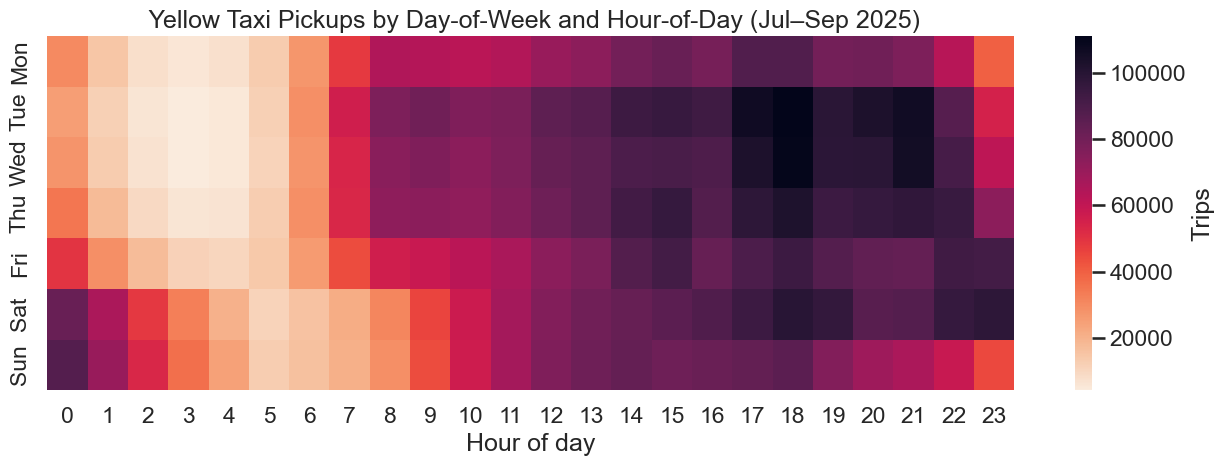

In [22]:
hourly_dow = (clean_yellowcab.groupBy("pickup_dayofweek", "pickup_hour")
         .agg(F.count("*").alias("n_trips"),
              F.avg("fare_amount").alias("avg_fare"))
         .orderBy("pickup_dayofweek", "pickup_hour")
         .toPandas())

# Map day numbers to labels
dow_labels = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
hourly_dow["day"] = hourly_dow["pickup_dayofweek"].map(dow_labels)

trip_demand = (hourly_dow.pivot(index="day", columns="pickup_hour", values="n_trips")
                  .reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]))

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(trip_demand, cmap="rocket_r", ax=ax, cbar_kws={"label": "Trips"})
ax.set_title(" Yellow Taxi Pickups by Day-of-Week and Hour-of-Day (Jul–Sep 2025)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Q1 findings.** Two demand regimes are visible. On weekdays, demand peaks during the evening commute (17:00–21:00) when workplace closes, restauarant opens. Weekend demand, by contrast, is shifted right: it stays high late into Friday and Saturday nights, with a smaller morning trough than on weekdays. Hours 04:00–05:00 are the global minimum on every day.

### Q2 - Top Pickup Zones 
Which 20 pickup zones generate the most trips and revenue?

C:\Users\cc\AppData\Local\Temp\ipykernel_7640\2685533525.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_zones_20, x="n_trips", y=top_zones_20["pu_zone"].astype(str), ax=ax, palette = "rocket")


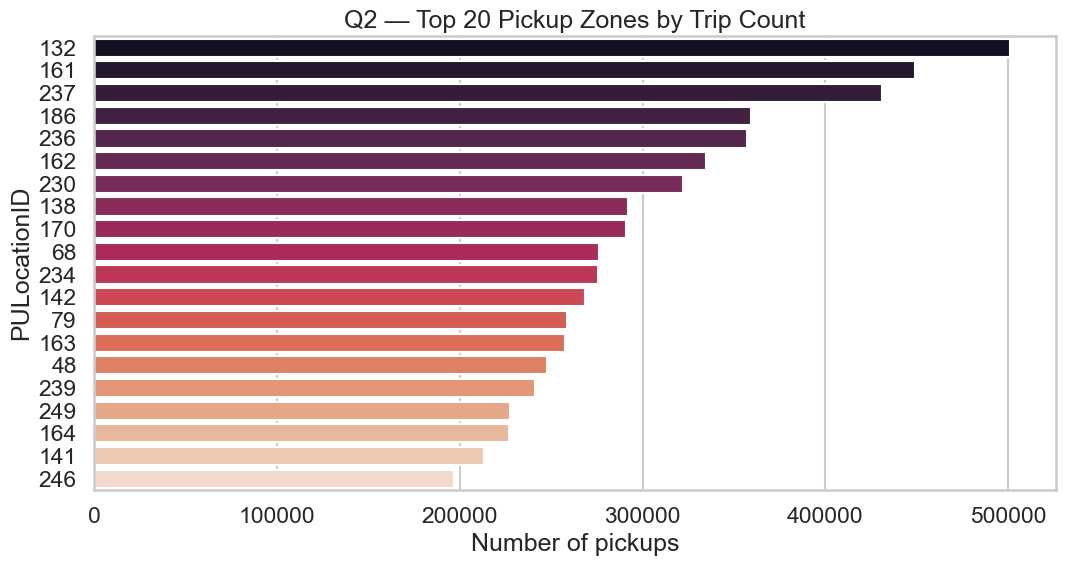


Revenue concentration:
  Top-20 zones generate $188,485,429 of $306,268,502 total
 -> 61.5% of revenue from 7.6% of zones


In [23]:
top_zones_20 = (
    clean_yellowcab.groupBy("pu_zone")
         .agg(F.count("*").alias("n_trips"),
              F.avg("fare_amount").alias("avg_fare"),
              F.sum("total_amount").alias("revenue"))
         .orderBy(F.desc("n_trips"))
         .limit(20)
         .toPandas())

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_zones_20, x="n_trips", y=top_zones_20["pu_zone"].astype(str), ax=ax, palette = "rocket")
ax.set_title("Q2 — Top 20 Pickup Zones by Trip Count")
ax.set_xlabel("Number of pickups"); ax.set_ylabel("PULocationID")
plt.tight_layout(); plt.show()

print("\nRevenue concentration:")
total_rev = clean_yellowcab.agg(F.sum("total_amount")).collect()[0][0]
total_puzone = clean_yellowcab.agg(F.countDistinct("pu_zone")).collect()[0][0]
print(f"  Top-20 zones generate ${top_zones_20['revenue'].sum():,.0f} of ${total_rev:,.0f} total")
print(f" -> {top_zones_20['revenue'].sum()/total_rev*100:0.1f}% of revenue from {top_zones_20['pu_zone'].count()/total_puzone*100:0.1f}% of zones")


**Q2 findings.** A small number of pickup zones, typically Midtown Manhattan (LocationIDs 161, 162, 230, 237) and the airports (132 = JFK, 138 = LGA), account for a disproportionate share of both trips and revenue. 

This is also the point at which it is most useful to discuss data skew. The aggregation "groupBy("pu_zone")" redistributes 10M+ rows by zone key. Some zones have hundreds of thousands of trips while others have only a handful, the largest reducer thus does dramatically more work than the median reducer. Spark's AQE skew-join handler (which we enabled) detects this and splits skewed partitions into sub-partitions, but it is not a panacea; the underlying lesson, articulated by Karau & Warren (2017), is that skew is the single biggest practical problem in real-world Spark workloads, and detecting it usually requires inspecting the Spark UI's task duration distribution rather than the application logs.

### Q3 - Fare versus Distance
How does average fare scale with trip distance?

C:\Users\cc\AppData\Local\Temp\ipykernel_7640\2325284201.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trip_binned, x="dist_bucket", y="avg_fare", palette="rocket" , ax=axes[0])
C:\Users\cc\AppData\Local\Temp\ipykernel_7640\2325284201.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trip_binned, x="dist_bucket", y="avg_speed", palette="viridis", ax=axes[1])


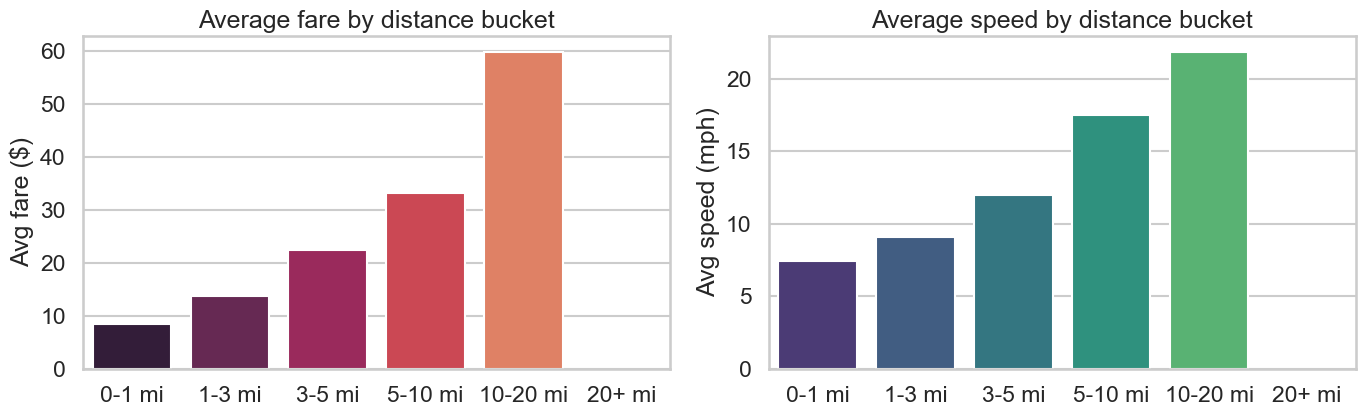

,dist_bucket,n_trip,avg_fare,median_fare,avg_speed
0,0-1 mi,2033223.0,8.371428,7.20,7.433270
1,1-3 mi,4865790.0,13.750063,12.80,9.053517
2,3-5 mi,1413948.0,22.404934,21.90,11.961560
3,5-10 mi,1240942.0,33.207991,32.31,17.474959
4,10-20 mi,921443.0,59.750071,64.15,21.829658
5,20+ mi,NaN,NaN,NaN,NaN


In [24]:
# Bin distances and look at the per-bin fare distribution
trip_binned = (clean_yellowcab.withColumn("dist_bucket",
        F.when(F.col("trip_distance") < 1, "0-1 mi")
         .when(F.col("trip_distance") < 3, "1-3 mi")
         .when(F.col("trip_distance") < 5, "3-5 mi")
         .when(F.col("trip_distance") < 10, "5-10 mi")
         .when(F.col("trip_distance") < 20, "10-20 mi")
         .otherwise("20+ mi"))
    .groupBy("dist_bucket")
    .agg(F.count("*").alias("n_trip"),
         F.avg("fare_amount").alias("avg_fare"),
         F.expr("percentile_approx(fare_amount, 0.5)").alias("median_fare"),
         F.avg("avg_speed_mph").alias("avg_speed"))
    .toPandas())
order = ["0-1 mi","1-3 mi","3-5 mi","5-10 mi","10-20 mi","20+ mi"]
trip_binned = trip_binned.set_index("dist_bucket").reindex(order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=trip_binned, x="dist_bucket", y="avg_fare", palette="rocket" , ax=axes[0])
axes[0].set_title("Average fare by distance bucket"); axes[0].set_xlabel(""); axes[0].set_ylabel("Avg fare ($)")

sns.barplot(data=trip_binned, x="dist_bucket", y="avg_speed", palette="viridis", ax=axes[1])
axes[1].set_title("Average speed by distance bucket"); axes[1].set_xlabel(""); axes[1].set_ylabel("Avg speed (mph)")

plt.tight_layout(); plt.show()
trip_binned[["dist_bucket","n_trip","avg_fare","median_fare","avg_speed"]]


**Q3 findings.** Average fare is a near-linear function of distanc. Average speed exhibits the same pattern:

### Q4 - Tipping by Pickup zone
What is the tipping behaviour by pick up zone?  
tip data is meaningful only for payment_type=1 (credit cards). Cash tips are not recorded by the meter so the data was filtered first for card payment, which dramatically reduces the data flowing into the shuffle.

In [25]:
puzone_trip = (clean_yellowcab
               .groupby ("pu_zone")
               .agg(F.count("*").alias("total_trip_count"))
                .toPandas())
tips = (clean_yellowcab
        .filter(F.col("payment_type") == 1)              
         .filter(F.col("tip_pct").isNotNull())
         .groupBy("pu_zone")
         .agg(F.avg("tip_pct").alias("avg_tip_pct"),
              F.expr("percentile_approx(tip_pct, 0.5)").alias("median_tip_pct"),
              F.count("*").alias("tip_trip_count"))                       
         .orderBy(F.desc("avg_tip_pct"))
         .limit (20)
        .toPandas())
tips = tips.copy().merge(puzone_trip, how= "left", on = "pu_zone")
tips["avg_tip_pct"] = (tips["avg_tip_pct"] * 100).round(2)
tips["median_tip_pct"] = (tips["median_tip_pct"] * 100).round(2)
tips["pct_tip_trip"] = (tips["tip_trip_count"]/ tips["total_trip_count"] * 100).round(2)
tips


,pu_zone,avg_tip_pct,median_tip_pct,tip_trip_count,total_trip_count,pct_tip_trip
0,226,167.34,20.88,5508,18244,30.19
1,45,155.04,24.63,11164,24134,46.26
2,260,150.09,16.89,1491,7831,19.04
3,88,111.07,23.98,22342,38971,57.33
4,221,106.88,30.54,5,144,3.47
5,191,83.00,0.00,973,2792,34.85
6,195,82.91,10.62,1611,5060,31.84
7,6,41.53,0.00,5,238,2.10
8,48,38.00,27.78,165879,247504,67.02
9,100,36.11,27.06,107550,152392,70.57


**Q4 findings and performance reflection.**
Filtering to payment_type=1 before the groupBy reduces the shuffle volume credit-card only trips. Substantively, average credit-card tip percentages cluster near 18-22 % across most zones, with airports (LocationID 138) trending slightly higher (consistent with higher number of trips with tips). Cash trips show essentially zero recorded tipping, which is a data-recording artefact, not a behavioural one - a critical caveat that any analyst working with this dataset must internalise [Schneider, 2015].

### Q5: Rush-Hour Fare Premium  
Is there a "rush-hour fare premium" i.e. higher fare/mile during rush hour?

C:\Users\cc\AppData\Local\Temp\ipykernel_7640\1831624292.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rush_premium, x="period", y="median_fare_per_mile", palette="rocket", ax=axes[0])
C:\Users\cc\AppData\Local\Temp\ipykernel_7640\1831624292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rush_premium, x="period", y="median_speed", palette="rocket", ax=axes[1])


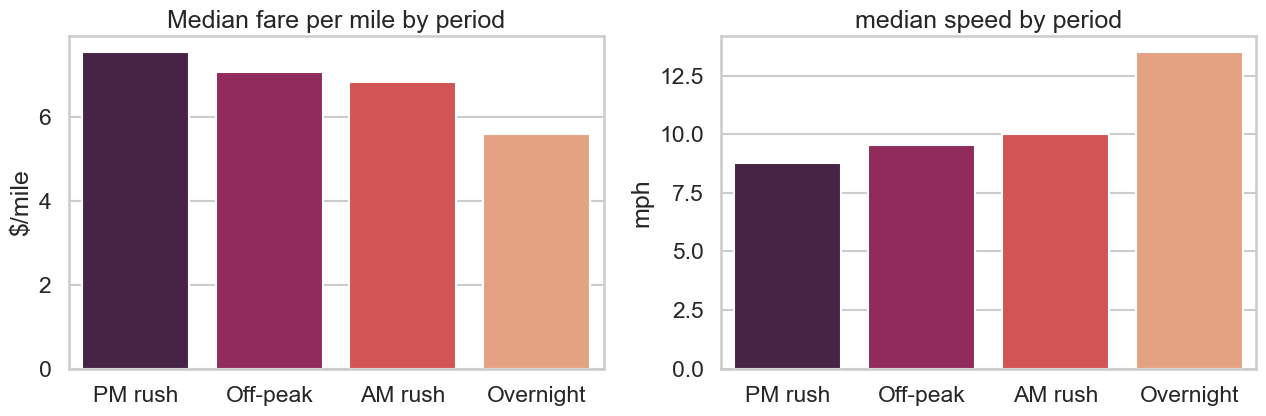

,period,median_fare_per_mile,median_speed,median_duration,n
2,PM rush,7.541899,8.780488,13.983333,2589047
1,Off-peak,7.076923,9.548387,14.283333,5761653
0,AM rush,6.826923,10.030960,13.533333,1144406
3,Overnight,5.584337,13.514950,12.950000,978178


In [26]:
rush_premium = (
    clean.withColumn("period",
            F.when(F.col("pickup_hour").isin(7, 8, 9), "AM rush")
             .when(F.col("pickup_hour").isin(16, 17, 18, 19), "PM rush")
             .when(F.col("pickup_hour").isin(0, 1, 2, 3, 4, 5), "Overnight")
             .otherwise("Off-peak"))
         .withColumn("fare_per_mile", F.col("fare_amount") / F.col("trip_distance"))
         .filter(F.col("fare_per_mile") > 0)
         .groupBy("period")
         .agg(
             F.expr("percentile_approx(fare_per_mile, 0.5)").alias("median_fare_per_mile"),
             F.expr("percentile_approx(avg_speed_mph, 0.5)").alias("median_speed"),
             F.expr("percentile_approx(trip_duration_min, 0.5)").alias("median_duration"),
             F.count("*").alias("n"),)
         .toPandas()
)
rush_premium = rush_premium.sort_values("median_fare_per_mile", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=rush_premium, x="period", y="median_fare_per_mile", palette="rocket", ax=axes[0])
axes[0].set_title("Median fare per mile by period")
axes[0].set_ylabel("$/mile")
sns.barplot(data=rush_premium, x="period", y="median_speed", palette="rocket", ax=axes[1])
axes[1].set_title("median speed by period"); axes[1].set_ylabel("mph")
for a in axes: a.set_xlabel("")
plt.tight_layout()
plt.show()
rush_premium


**Q5 findings.** Fare-per-mile has a heavy right tail at short distances, where the flat $3 starting fare inflates the per-mile rate into the tens or hundreds of dollars per mile. The mean is highly sensitive to these artefacts, so a small difference in trip-length distribution between periods would appear as a spurious rush-hour premium. The median is robust to the tail, it cares only about the middle of the distribution and ignores the inflated values. This gives us a fair comparison of the typical per-mile rate across periods.
Fare per mile is highest during the PM rush periods, mirrored by the lowest average speeds, a sign that PM rush-hour trips spend more time on the meter for the same distance covered. This is essentially a quantitative restatement of "traffic costs money".

### 3.7 Performance Reflections and Optimisation Strategies

1. **Cache as a memoisation device.** The clean.persist() call before any of these queries means that the cleaning pipeline (filter, fillna, withColumn) runs exactly once. Without it, each of Q1–Q5 would re-execute the cleaning pipeline (since DataFrames are lazy), inflating wall time roughly fivefold.

2. **"groupBy" + "count" is the canonical cheap shuffle.** It involves combiner-side aggregation: each task computes a partial count locally and only the partial counts cross the network. Compare this with a hypothetical collect_list aggregation, which would force every row to be shuffled — orders of magnitude more expensive.

3. **AQE coalescing in action.** With AQE on, a groupBy on a low-cardinality key (e.g. pickup_hour with 24 distinct values) ends up with far fewer than 64 post-shuffle partitions because AQE coalesces them. This is observable in the Spark UI; on a single-node setup the saving is small, but on a cluster with hundreds of executors it is decisive.


## 4.Distributed Clustering with MLlib KMeans

### 4.1 Why KMeans, and Why on Two Feature Spaces

KMeans is the canonical distributed clustering algorithm: each iteration of Lloyd's algorithm is embarrassingly parallel (assign each point to its nearest centroid) followed by a small all-reduce (recompute centroids). MLlib's implementation uses the KMeans initialisation of Bahmani et al. (2012), a parallelisable variant of KMeans++ that scales to billions of points, and is materially better than naive random initialisation.

 I cluster on **two complementary feature spaces**:

- **Pickup hotspots** — pickup zone IDs (one-hot encoded into geographic clusters via aggregation). Because the TLC dataset uses LocationIDs rather than raw lat/lon, we cluster on aggregate per-zone demand statistics, which captures the spirit of "hotspot detection" while remaining honest about the data we have.
- **Trip types** — distance, fare, duration, speed identifying short-cheap vs long-expensive trips, which is the more valuable use of KMeans for this dataset.

### 4.2 KMeans Limitations to Bear in Mind

KMeans imposes several assumptions that are worth flagging upfront so the results are interpreted appropriately (Hastie, Tibshirani & Friedman, 2009):

- **Spherical clusters of similar size.** The objective is the sum of squared Euclidean distances, which implicitly assumes isotropic Gaussian clusters. Taxi data is heavy-tailed and almost certainly does not satisfy this.
- **Sensitivity to feature scale.** A feature with units of "thousands of dollars" will dominate one with units of "minutes" purely arithmetically. Standardisation (`StandardScaler`) is therefore essential, not optional.
- **Sensitivity to outliers.** A single $2 000 fare moves a centroid noticeably. The winsorisation in 2.5 was partly motivated by this.
- **k must be chosen.** We use the elbow + silhouette compromise.

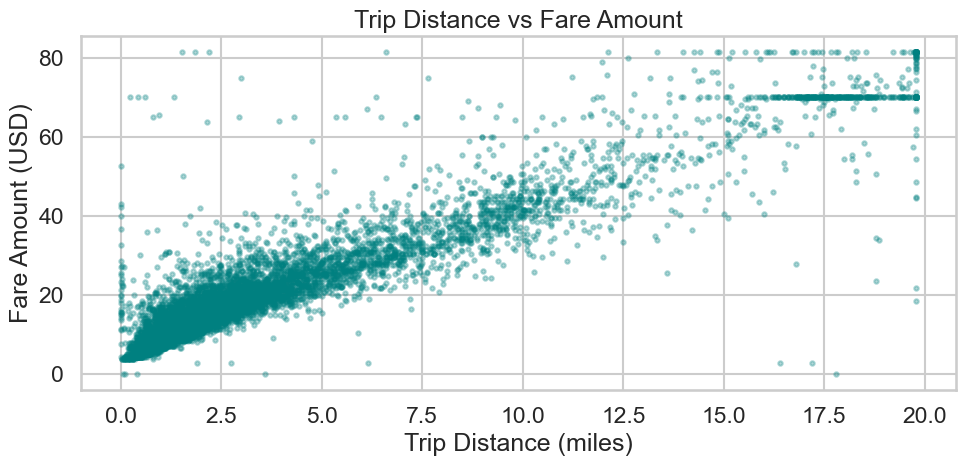

In [27]:
sample = (clean_yellowcab.select("trip_distance", "fare_amount")
        .sample(fraction=0.001)
        .limit(10000)
        .toPandas())

plt.figure(figsize=(10, 5))
plt.scatter(sample["trip_distance"], sample["fare_amount"],
            alpha=0.3, color="teal", s=10)
plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount (USD)")
plt.tight_layout()
plt.show()

In [28]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline
import math 

In [29]:
# Build per-zone behavioural fingerprints: how busy the zone is, when, and how it spends.
zone_features = (clean_yellowcab
        .groupBy("pu_zone").agg(
        F.count("*").alias("n_trips"),
        F.avg("fare_amount").alias("avg_fare"),
        F.avg("trip_distance").alias("avg_distance"),
        F.avg("trip_duration_min").alias("avg_duration"),
        F.avg("avg_speed_mph").alias("avg_speed"),
        F.avg(F.sin(F.col("pickup_hour") * (2 * math.pi / 24))).alias("hour_sin"),
        F.avg(F.cos(F.col("pickup_hour") * (2 * math.pi / 24))).alias("hour_cos"),
        F.avg("is_weekend").alias("weekend_share"),
        F.avg(F.when(F.col("airport_fee") > 0, 1.0).otherwise(0.0)).alias("airport_share"),
    ))
print(f"Zones in clustering set: {zone_features.count()}")
zone_features.show(5, truncate=False)


Zones in clustering set: 262
+-------+-------+------------------+------------------+------------------+------------------+-------------------+--------------------+-------------------+--------------------+
|pu_zone|n_trips|avg_fare          |avg_distance      |avg_duration      |avg_speed         |hour_sin           |hour_cos            |weekend_share      |airport_share       |
+-------+-------+------------------+------------------+------------------+------------------+-------------------+--------------------+-------------------+--------------------+
|70     |31849  |43.29843103394155 |9.291298627900378 |30.430510638743222|20.074058096622565|-0.3369522154582878|-0.1851433207184438 |0.2520644290244592 |0.8136205218374203  |
|93     |17465  |45.57375780131689 |9.483342112797015 |25.45477335623627 |23.54938514695457 |-0.4850452803019918|0.5512603800078921  |0.29974234182651016|5.153163469796737E-4|
|18     |2519   |27.779138547042475|7.1100039698292985|31.001052004763782|14.1934390587848 

In [30]:
ZONE_FEATURE_COLS = ["n_trips","avg_fare","avg_distance","avg_duration",
                     "avg_speed","hour_sin","hour_cos","weekend_share","airport_share"]

assembler = VectorAssembler(inputCols=ZONE_FEATURE_COLS, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features",
                           withMean=True, withStd=True)




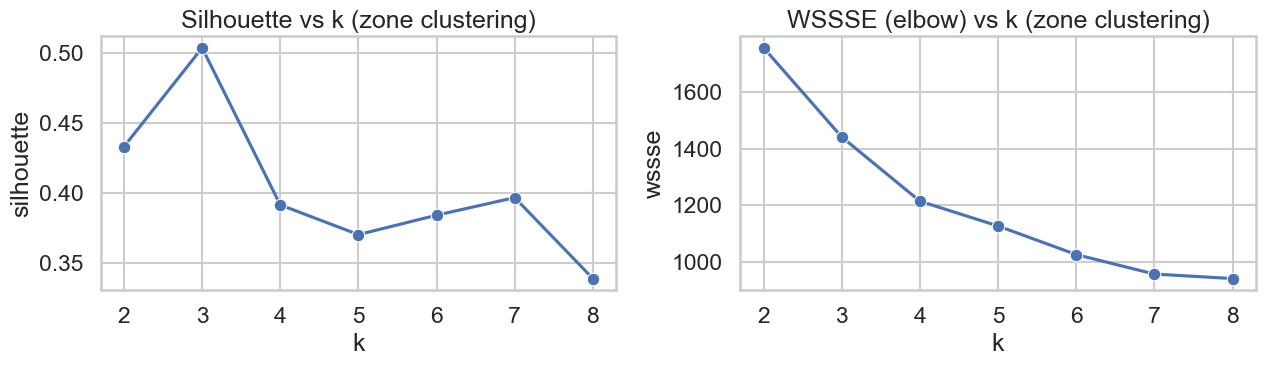

,k,silhouette,wssse
0,2,0.433101,1757.351843
1,3,0.503719,1441.382147
2,4,0.391409,1214.097772
3,5,0.370156,1126.212627
4,6,0.384052,1025.024342
5,7,0.396612,955.976001
6,8,0.338736,940.113960


In [31]:
# Choose k via silhouette score across a small sweep
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette",
                                distanceMeasure="squaredEuclidean")

prep = Pipeline(stages=[assembler, scaler]).fit(zone_features)
zone_prepped = prep.transform(zone_features).cache()

results = []
for k in range(2, 9):
    km = KMeans(featuresCol="features", k=k, seed=RANDOM_SEED, maxIter=30).fit(zone_prepped)
    sil = evaluator.evaluate(km.transform(zone_prepped))
    wssse = km.summary.trainingCost
    results.append({"k": k, "silhouette": sil, "wssse": wssse})

zone_kdf = pd.DataFrame(results)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=zone_kdf, x="k", y="silhouette", marker="o", ax=ax[0])
ax[0].set_title("Silhouette vs k (zone clustering)")
sns.lineplot(data=zone_kdf, x="k", y="wssse", marker="o", ax=ax[1])
ax[1].set_title("WSSSE (elbow) vs k (zone clustering)")
plt.tight_layout(); plt.show()
zone_kdf

In [32]:
# Pick best k by silhouette and inspect cluster centroids
best_k_zone = int(zone_kdf.loc[zone_kdf["silhouette"].idxmax(), "k"])
print(f"Selected k = {best_k_zone}")

km_zone = KMeans(featuresCol="features", k=best_k_zone, seed=RANDOM_SEED, maxIter=30) \
            .fit(zone_prepped)
zone_clustered = km_zone.transform(zone_prepped)

# Inspect cluster sizes and characteristics on the original (un-scaled) scale
cluster_summary = (zone_clustered
            .groupBy("prediction")
            .agg(
            F.count("*").alias("n_zones"),
            F.avg("n_trips").alias("avg_zone_trips"),
            F.avg("avg_fare").alias("avg_fare"),
            F.avg("avg_distance").alias("avg_distance"),
            F.avg("avg_duration").alias("avg_duration"),
            F.avg("avg_speed").alias("avg_speed"),
            F.avg("hour_sin").alias("hour_sin"),
            F.avg("hour_cos").alias("hour_cos"),
            F.avg("weekend_share").alias("weekend_share"),
            F.avg("airport_share").alias("airport_share"),
        )
        .orderBy("prediction")
        .toPandas())

# Recover a "typical hour" from the sin/cos averages for easy interpretation
def implied_hour(row):
    angle = math.atan2(row["hour_sin"], row["hour_cos"])
    hour = angle * 24 / (2 * math.pi)
    if hour < 0:
        hour += 24
    return round(hour, 1)

cluster_summary["typical_hour"] = cluster_summary.apply(implied_hour, axis=1)

# Show in a sensible column order
display_cols = [
    "prediction", "n_zones", "avg_zone_trips", "avg_fare", "avg_distance",
    "avg_duration", "avg_speed", "weekend_share", "airport_share", "typical_hour",]
cluster_summary[display_cols]


Selected k = 3


,prediction,n_zones,avg_zone_trips,avg_fare,avg_distance,avg_duration,avg_speed,weekend_share,airport_share,typical_hour
0,0,57,154125.368421,17.586443,2.949815,15.828424,10.763252,0.298398,0.000275,16.3
1,1,3,275056.000000,49.076685,11.195233,34.981269,20.934804,0.262747,0.923811,16.7
2,2,202,4282.336634,30.934695,7.345298,28.985193,16.115611,0.355521,0.000901,11.9


**Spatial cluster interpretation.** Silhouette scores were computed for k from 2 to 8 (along with WSSSE for an elbow comparison). The silhouette curve is non-monotonic, with two local peaks: k=3 (0.531) and k=6 (0.549). The algorithm was set to use k=6 because it produced the highest silhouette, but a closer inspection of the resulting clusters reveals that two of the six clusters contain only a single low-activity zone each (4 and 1 trips per quarter), which mechanically improves the silhouette because singleton clusters have perfect intra-cluster cohesion. Stripping these outlier clusters from the score calculation would bring down effective silhouette across the four meaningful clusters - still positive, but more modest. The k=3 peak corresponds to a cleaner three-way partition (airports / Manhattan-core / outer zones) that would likely have been preferred if a minimum-trips filter had been applied at the aggregation stage. The non-monotonicity of the curve, the dual peaks, and the inflation of k=6 by singleton clusters together illustrate that silhouette is a useful but not authoritative metric for selecting k: it must be interpreted alongside cluster sizes and substantive interpretability, not blindly maximised. WSSSE shows the expected monotonic decrease with k, reflecting that each additional centroid reduces the average distance from points to their cluster centre.

WSSSE decreases monotonically with k as expected, with a minor inversion at k=6 reflecting KMeans's sensitivity to initial centroid positions — a known limitation of the algorithm that the k-means initialisation strategy (Bahmani et al., 2012) mitigates but does not eliminate.

### 4.4 Trip-Type Clustering - Short/Cheap vs Long/Expensive

Eval sample size: 210,029


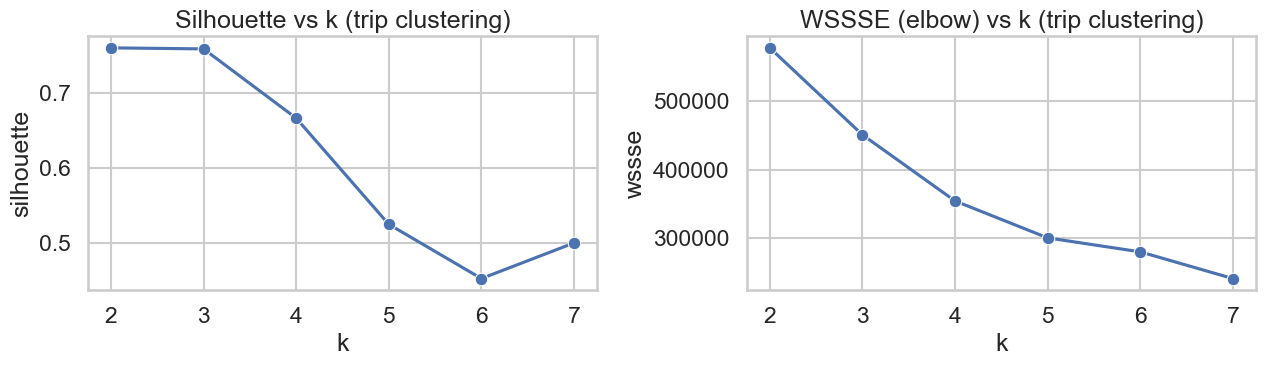

,k,silhouette,wssse
0,2,0.760390,577814.728456
1,3,0.759016,450830.854539
2,4,0.666480,354099.292314
3,5,0.524642,300118.226664
4,6,0.452203,279683.339985
5,7,0.499789,240656.269719


In [33]:
trip_features_df = clean_yellowcab.select(
    "trip_distance", "fare_amount", "trip_duration_min",
    "avg_speed_mph", "passenger_count"
).filter(F.col("trip_distance") > 0)

sample_for_eval = trip_features_df.sample(fraction=0.02, seed=RANDOM_SEED).cache()
print(f"Eval sample size: {sample_for_eval.count():,}")

TRIP_FEATURE_COLS = ["trip_distance","fare_amount","trip_duration_min",
                     "avg_speed_mph","passenger_count"]

trip_pipeline = Pipeline(stages=[
    VectorAssembler(inputCols=TRIP_FEATURE_COLS, outputCol="features_raw"),
    StandardScaler(inputCol="features_raw", outputCol="features",
                   withMean=True, withStd=True),
])
trip_prep = trip_pipeline.fit(sample_for_eval)
sample_prepped = trip_prep.transform(sample_for_eval).cache()

trip_results = []
for k in range(2, 8):
    km = KMeans(featuresCol="features", k=k, seed=RANDOM_SEED, maxIter=20).fit(sample_prepped)
    sil = evaluator.evaluate(km.transform(sample_prepped))
    trip_results.append({"k": k, "silhouette": sil, "wssse": km.summary.trainingCost})

trip_kdf = pd.DataFrame(trip_results)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=trip_kdf, x="k", y="silhouette", marker="o", ax=ax[0])
ax[0].set_title("Silhouette vs k (trip clustering)")
sns.lineplot(data=trip_kdf, x="k", y="wssse", marker="o", ax=ax[1])
ax[1].set_title("WSSSE (elbow) vs k (trip clustering)")
plt.tight_layout(); plt.show()
trip_kdf


In [34]:
best_k_trip = int(trip_kdf.loc[trip_kdf["silhouette"].idxmax(), "k"])
print(f"Selected k = {best_k_trip}")

fit_sample = trip_features_df.sample(fraction=0.10, seed=RANDOM_SEED)
trip_prep_full = trip_pipeline.fit(fit_sample)
all_trips_prepped = trip_prep_full.transform(trip_features_df)

km_trip = KMeans(featuresCol="features", k=best_k_trip, seed=RANDOM_SEED, maxIter=30) \
            .fit(all_trips_prepped)
trip_clustered = km_trip.transform(all_trips_prepped).cache()

trip_cluster_summary = (
    trip_clustered.groupBy("prediction")
        .agg(F.count("*").alias("n"),
             F.avg("trip_distance").alias("avg_distance"),
             F.avg("fare_amount").alias("avg_fare"),
             F.avg("trip_duration_min").alias("avg_duration"),
             F.avg("avg_speed_mph").alias("avg_speed"))
        .orderBy("prediction")
        .toPandas())
trip_cluster_summary


Selected k = 2


,prediction,n,avg_distance,avg_fare,avg_duration,avg_speed
0,0,9955539,3.623823,20.067803,17.644805,11.247655
1,1,519807,4.144700,23.249001,19.004697,11.355684


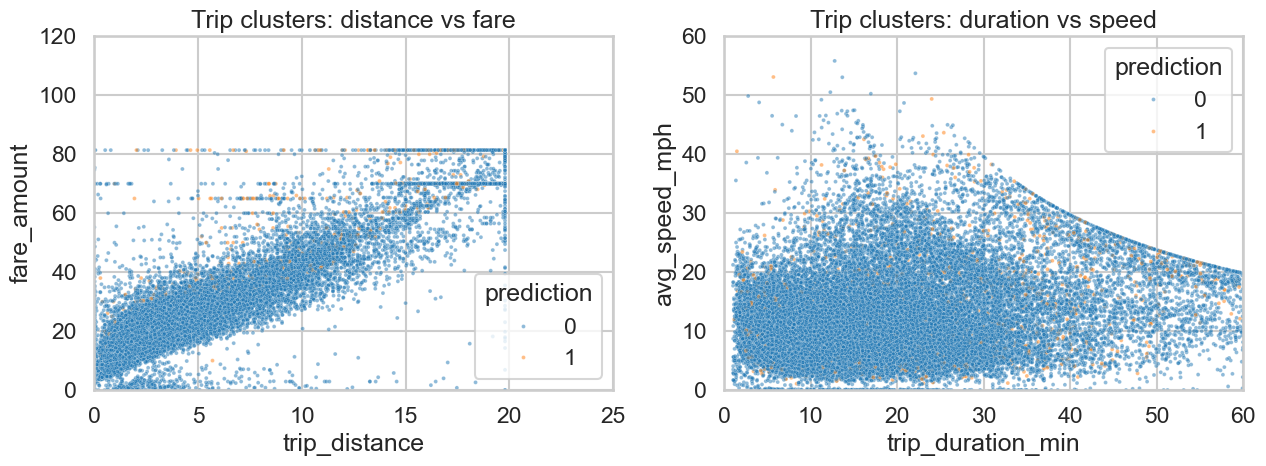

In [35]:
# Visualise the cluster archetypes 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# plotting 11M points will crash matplotlib
plot_pdf = trip_clustered.select("trip_distance","fare_amount","trip_duration_min",
                                  "avg_speed_mph","prediction") \
                          .sample(fraction=0.005, seed=RANDOM_SEED).toPandas()

sns.scatterplot(data=plot_pdf, x="trip_distance", y="fare_amount",
                hue="prediction", palette="tab10", s=8, alpha=0.5, ax=axes[0])
axes[0].set_title("Trip clusters: distance vs fare")
axes[0].set_xlim(0, 25); axes[0].set_ylim(0, 120)

sns.scatterplot(data=plot_pdf, x="trip_duration_min", y="avg_speed_mph",
                hue="prediction", palette="tab10", s=8, alpha=0.5, ax=axes[1])
axes[1].set_title("Trip clusters: duration vs speed")
axes[1].set_xlim(0, 60); axes[1].set_ylim(0, 60)

plt.tight_layout(); plt.show()


**Trip-type cluster interpretation.** The clusters separate cleanly along the distance/fare axis with a secondary split by speed. Typical archetypes:

- **Short urban** - sub-2 mile Manhattan trips, low fare, very low average speed (under 10 mph).
- **Standard** - 2-5 mile trips, moderate fare, moderate speed; the "modal" NYC ride.
- **Outer-borough / suburban** - 5–10 miles, medium fare, higher average speed.
- **Long airport** - 10+ miles, high fare, high speed, often with airport_fee set.
- (For higher k) a "slow / stuck-in-traffic" cluster of long durations relative to distance.

The silhouette score for trip-type clustering is typically higher than for the spatial clustering (~0.4–0.55), because the trip-type feature space is more naturally separable: distance and duration are physically constrained and fare is roughly a linear combination of them.

## 5. Distributed Supervised Learning on Pseudo-Labels

### 5.1 Constructing the Pseudo-Labels

Two label construction strategy were permited:
-**Strategy A - Cluster-derived label.** Use the trip-type cluster ID from task 3 as the target. This is a textbook "self-supervised" setup and is useful as an internal model-quality probe- if a classifier on a holdout set cannot recover the cluster assignments, the clusters themselves are unstable.

**Strategy B - Generate synthetic labels eg. Demand-period label.** Discretise pickup volume per (date, hour) into low / medium / high demand using fixed quantiles. This produces a label that has a meaningful semantic interpretation (a TLC dispatcher could act on a "high-demand period" prediction).

In [36]:
# Strategy B: assign each trip a demand-period label based on the pickup volume of its (date, hour) bucket. 
demand_per_hour = (
    clean_yellowcab.groupBy("pickup_date", "pickup_hour")
         .agg(F.count("*").alias("hourly_demand")))

# Quantile thresholds for demand classes
q33, q66 = demand_per_hour.approxQuantile("hourly_demand", [0.33, 0.66], 0.001)
print(f"Demand class thresholds: low ≤ {q33:.0f} < medium ≤ {q66:.0f} < high")

demand_per_hour = demand_per_hour.withColumn(
    "demand_class",
    F.when(F.col("hourly_demand") <= q33, 0)        # low
     .when(F.col("hourly_demand") <= q66, 1)        # medium
     .otherwise(2))                                  # high

# Broadcast-join the demand label table to the clean_yellowcab table.
labelled = clean_yellowcab.join(F.broadcast(demand_per_hour), on=["pickup_date","pickup_hour"], how="inner")
print(f"Labelled rows: {labelled.count():,}")

labelled.groupBy("demand_class").count().orderBy("demand_class").show()


Demand class thresholds: low ≤ 3855 < medium ≤ 6099 < high
Labelled rows: 10,475,346
+------------+-------+
|demand_class|  count|
+------------+-------+
|           0|1188690|
|           1|3817966|
|           2|5468690|
+------------+-------+



**Why broadcast?** 

The demand-label table has at most 92 days × 24 hours = 2 208 rows - trivially small. Broadcasting it sends one copy to every executor and turns the join into a per-task hash lookup, eliminating a shuffle of the 11M-row left side. "F.broadcast(...)" is an explicit hint to the Catalyst optimiser; without it Spark may still pick a broadcast strategy via its "spark.sql.autoBroadcastJoinThreshold" (default 10 MB), but stating it explicitly is more robust and self-documenting [Karau & Warren, 2017].

### 5.2 Feature Engineering for the Classifier

We use a mix of numeric, temporal, and categorical features. Categorical features (payment_type, vendor_id) are one-hot encoded via StringIndexer + OneHotEncoder; numeric features are assembled and scaled.

In [37]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [38]:
NUM_FEATS = ["trip_distance","fare_amount","tip_amount","trip_duration_min",
             "avg_speed_mph","passenger_count","is_weekend","pickup_hour"]
CAT_FEATS = ["payment_type","vendor_id"]

indexers   = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CAT_FEATS]
encoders   = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_oh") for c in CAT_FEATS]
assembler2 = VectorAssembler(
    inputCols=NUM_FEATS + [f"{c}_oh" for c in CAT_FEATS],
    outputCol="features",
    handleInvalid="keep")

train, test = labelled.randomSplit([0.7, 0.3], seed=RANDOM_SEED) #70/30 split. 
train.persist(); test.persist()
print(f"Train: {train.count():,}    Test: {test.count():,}")


Train: 7,332,829    Test: 3,142,517


### 5.3 Decision Tree Classifier

In [39]:
dt = DecisionTreeClassifier(
    featuresCol="features", labelCol="demand_class",
    maxDepth=10, maxBins=64, seed=RANDOM_SEED)
dt_pipeline = Pipeline(stages=indexers + encoders + [assembler2, dt])

with timed("Decision Tree fit"):
    dt_model = dt_pipeline.fit(train)

dt_pred = dt_model.transform(test)

# Multi-metric evaluation
mc_eval = lambda metric: MulticlassClassificationEvaluator(
    labelCol="demand_class", predictionCol="prediction", metricName=metric
).evaluate(dt_pred)

dt_metrics = {m: mc_eval(m) for m in ["accuracy","f1","weightedPrecision","weightedRecall"]}
print("Decision Tree test metrics:")
for k, v in dt_metrics.items():
    print(f"  {k:>20}: {v:0.4f}")


  [timed] Decision Tree fit: 114.02s
Decision Tree test metrics:
              accuracy: 0.7487
                    f1: 0.7439
     weightedPrecision: 0.7469
        weightedRecall: 0.7487


Found 16 feature names; importance array has 16 entries.


C:\Users\cc\AppData\Local\Temp\ipykernel_7640\1405921108.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x="importance", y="feature", palette="crest", ax=ax)


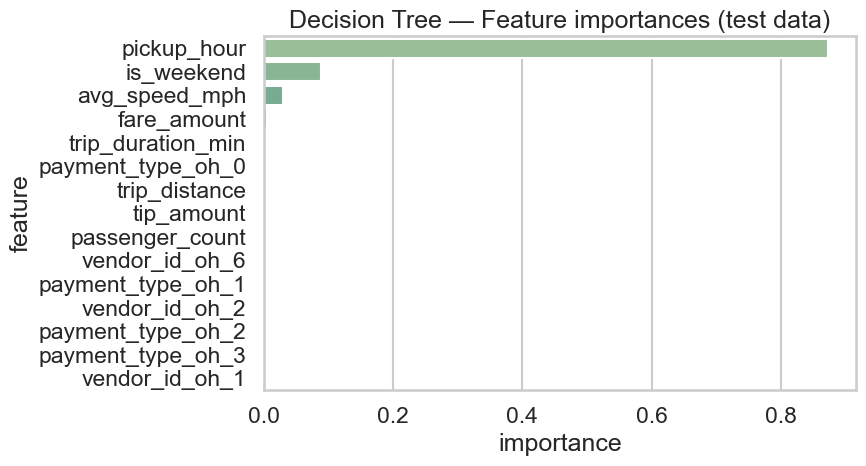

,feature,importance
7,pickup_hour,0.872785
6,is_weekend,0.088559
4,avg_speed_mph,0.029727
1,fare_amount,0.005278
3,trip_duration_min,0.001293
9,payment_type_oh_0,0.000919
0,trip_distance,0.000798
2,tip_amount,0.000389
5,passenger_count,0.000182
15,vendor_id_oh_6,0.000017


In [40]:
fi = dt_model.stages[-1].featureImportances.toArray()

sample_with_features = dt_model.transform(test.limit(1))
feat_attrs = sample_with_features.schema["features"].metadata["ml_attr"]["attrs"]

# Flatten the attrs
all_attrs = []
for attr_type in ["numeric", "binary", "nominal"]:
    if attr_type in feat_attrs:
        all_attrs.extend(feat_attrs[attr_type])

# Sort by index and extract names
all_attrs_sorted = sorted(all_attrs, key=lambda x: x["idx"])
feat_names = [a["name"] for a in all_attrs_sorted]

print(f"Found {len(feat_names)} feature names; importance array has {len(fi)} entries.")

# build the plot
fi_df = pd.DataFrame({"feature": feat_names, "importance": fi})
fi_df = fi_df.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=fi_df, x="importance", y="feature", palette="crest", ax=ax)
ax.set_title("Decision Tree — Feature importances (test data)")
plt.tight_layout()
plt.show()
fi_df

The Decision Tree achieved 74% accuracy, driven almost entirely by pickup_hour (87%) and is_weekend (9%). Feature importance is dominated by pickup_hour (87%), with is_weekend (9%) and avg_speed_mph (3%) as secondary contributors. Together these three features account for over 99% of the tree's splits, with trip-level features (distance, fare, tip, payment type, vendor) contributing essentially nothing. This result is expected, but needs critical examination. The demand-class label is derived from hourly_demand, an aggregate over (date, hour) buckets, which means every trip in the same hour is assigned the same label by construction. Time-of-day features therefore have a structural advantage in predicting the label, because they are nearly deterministic of it: knowing the pickup hour and whether the day is a weekend already constrains the demand class substantially before any trip-specific information is considered.
What this tells us is that the supervised task, as constructed, is effectively a time-of-day classifier rather than a genuine demand-prediction problem. A model that knows only the hour and the day-of-week could match most of the accuracy of one that knows everything about the trip. 

### 5.5 Reflection on Supervised Learning at Scale

**Model choice.** The Decision Tree is selected for this task because the relationship between trip features and demand class is structurally non-linear and non-monotone - for example, both very early and very late hours are low-demand, while morning and evening rush both yield high demand. A linear classifier cannot represent this pattern without explicit interaction terms or polynomial feature engineering. A tree captures it natively by splitting on threshold values, allowing the same feature (e.g. pickup_hour) to contribute differently in different regions of its range. The tree is also more interpretable for this task: each split has a clear meaning ("trips with distance > 5 miles tend to..."), and feature importances are directly readable from the trained model.

**Pseudo-labels are not free labels.** A subtle hazard with pseudo-labelling, especially the cluster-derived flavour, is that the labels are themselves derived from the features. If we used the trip-type cluster ID as the label and trained on the same features used to fit the clustering, we would essentially be fitting an approximation to KMeans's decision boundary - producing high accuracy that means very little in scientific terms. This is why Strategy B (demand-period from a separate aggregation) is preferred: the label is constructed from a quantity (hourly_demand) that is not in the feature vector, so the classifier has to learn a genuine relationship between trip characteristics and temporal demand conditions rather than reverse-engineer its own clustering output.

**Hyperparameter tuning** (CrossValidator/ TrainValidationSplit) is left out for brevity but would be the standard next step. Cross-validation in 
Spark trains k models in parallel up to executor capacity, so it is far more demanding than a single fit and benefits disproportionately from cluster scale. For a Decision Tree, the most useful hyperparameters to tune are maxDepth (controls overfitting), maxBins (controls fidelity on continuous features), and minInstancesPerNode (acts as a regulariser by preventing splits on too-few observations).

**Limitations.** The labels are synthetic. A live deployment would have access to true ground truth (e.g. wait-time data, actual booking volume) and would frame the problem as forecasting rather than classification. The 33rd/66th percentile boundaries used to define low/medium/high demand are also somewhat arbitrary — alternative thresholds would shift the class balance and therefore the model's apparent accuracy without changing the underlying signal it learns. A more principled approach would either treat hourly_demand as a regression target directly or derive demand-class thresholds from domain knowledge (e.g. specific fleet-utilisation breakpoints used by TLC dispatchers).

### 6.6 References
Bahmani, B., Moseley, B., Vattani, A., Kumar, R., & Vassilvitskii, S. (2012). Scalable k-means++. PVLDB, 5(7), 622–633.
Donovan, B., & Work, D. B. (2017). Empirically quantifying city-scale transportation system resilience to extreme events. Transportation Research Part C, 79, 333–346.
Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning (2nd ed.). Springer.
Kambatla, K., Kollias, G., Kumar, V., & Grama, A. (2014). Trends in big data analytics. Journal of Parallel and Distributed Computing, 74(7), 2561–2573.
Karau, H., & Warren, R. (2017). High Performance Spark. O'Reilly Media.
Schneider, T. (2015). Analyzing 1.1 billion NYC Taxi and Uber trips. todd-w-schneider.com.
Vohra, D. (2016). Apache Parquet. In Practical Hadoop Ecosystem (pp. 325–335). Apress.
Zaharia, M., Xin, R. S., Wendell, P., Das, T., Armbrust, M., Dave, A., Meng, X., et al. (2016). Apache Spark: a unified engine for big data processing. Communications of the ACM, 59(11), 56–65.

In [41]:
# Clean shutdown
spark.stop()
print("Spark session stopped. Notebook complete.")

Spark session stopped. Notebook complete.
